
# Monte Carlo — Workshop 1 *Monte Carlo practise*

This notebook accompanies **Lecture 2 (Advanced sampling and reweighting)**.  
It contains one **fully worked example** and a sequence of **exercises** to complete at the end of the lecture and in the accompanying workshop.

**Learning goals**
After completing all exercise in this notebook, you will be able to:
1. Implement and validate basic sampling algorithms
2. Generate random samples using inversion and hit–miss methods.
3. Use analytical and numerical validation (overlaid histograms, ratio plots, $\chi^2$/ndf).
4. Use and design efficient overestimates
5. Construct piecewise or analytical envelope functions 
6. Apply reweighting to modify simulated ensembles
7. Compute event weights and build weighted histograms.
8. Quantify the effective sample size ($\mu_{eff}$) and understand ensemble overlap.
9. Connect acceptance–rejection and reweighting, recognizing hit–miss and weighted sampling as two views of the same algorithmic geometry.
10. Explain when reweighting works well and when it fails.

> Conventions: keep code simple and readable; prefer small testable functions; validate with overlays, ratio plots and $\chi^2/$ndf where applicable.

**Approach**
- Begin with reading the worked example, make sure that you understand what is going on.
- Do the first exercise.
- Continue with exercises until you have spent no more than 45 minutes, even if you have not completed the first exercise yet.
- Proceed with the biased coin toss exercise (exercise 6: main task).
- If you finish, you can go back and do the rest of the exercises from the beginning.
- This is all to say: Exercises 3-5 are not easy! They are the practical introduction to some of the (valuable!) techniques we have been through in the lecture, but completing them may take time. Your primary focus should be the coin toss example, since it will be more valuable for the project, and secondary completing all aspects of the rest of the exercises.



## 1. Fully worked example — Inversion sampling (Exponential)

We wish to sample the distribution
$$
f(x) = \lambda e^{-\lambda x}, x \in [0,\infty)
$$
for the following values of the parameter $\lambda$:
$$
\lambda = \{2.0, 4.0, 6.0\}
$$
The function has an analytical primitive which is invertible:
$$
F(x) = -e^{-\lambda x} = u \Leftrightarrow x = -\ln(-u)/\lambda
$$
So, with $R$ being a random number, we have (inserting limits):
$$
x = F^{-1}\left( F(x_{min}) + R[F(x_{max}) - F(x_{min})])\right) = F^{-1}\left(-1 + R(0 + 1)\right) = F ^{-1}\left(-(1-R)\right)=F ^{-1}\left(-R\right).
$$
In the last step using that $1-R = R$ by definition. Plugging in $F^{-1}$ from above:
$$
x = -\ln(R)/\lambda
$$

We validate by overlaying histogram and analytic pdf, reproducing the plot from the first lecture without resorting to numpys samples.


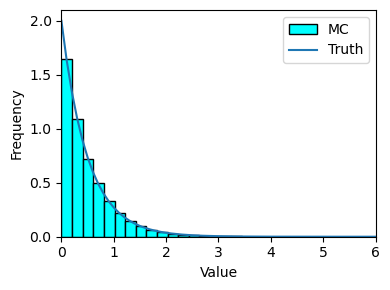

In [2]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(12345)

# Exponential pdf
def pdf_exp(x, lam):
    return lam * np.exp(-lam*x)

# Inversion sampler
def sample_exp(n, lam):
    R = rng.random(n)                # in [0,1)
    return -np.log(R) / lam
    
lam = 2.0 # Change lambda = {2, 4, 6} here
samples = sample_exp(100_000, lam) # Generate the 100k samples

fig, ax = plt.subplots(figsize=(4, 3))
# Make a histogram, normalized.
ax.hist(samples, bins=30, density=True, color='cyan', edgecolor='black', label='MC')

# Overlay with the theoretical pdf.
x = np.array([0.1 * i for i in range(0,200)])
ax.plot(x, pdf_exp(x, lam), label='Truth')
ax.set_xlabel("Value")
ax.set_ylabel("Frequency"); ax.set_xlim(0,6); ax.legend()
plt.tight_layout()

plt.show()


## 2. Exercise — Inversion sampling (linear)

Target function:
$$
f(x) = 2x, \quad x\in[0,1].
$$

**Tasks**
1. Calculate the primitive $F(x)$ and invert it.
2. Plug in to the formula for sampling $x$.
3. Implement `sample_linear(n)` using inversion.
2. Validate by overlaying with the theoretical curve.


/opt/homebrew/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


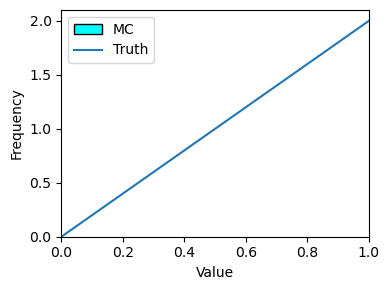

In [4]:

def pdf_linear(x):
    return 2*x

def sample_linear(n):
    # TODO: implement inversion sampling for f(x) = 2x on [0,1]
    return []

samples = sample_linear(100_000)

fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(samples, bins=10, density=True, color='cyan', edgecolor='black', label='MC')

x = np.array([0.1 * i for i in range(0,11)])
ax.plot(x, pdf_linear(x), label='Truth')
ax.set_xlabel("Value")
ax.set_ylabel("Frequency"); ax.set_xlim(0,1); ax.legend()
plt.tight_layout()



## 3. Exercise — Hit‑and‑miss (accept/reject)

Sample from:

$$
f(x) = 2\sin^2(\pi x), \quad x\in[0,1].
$$
Use the simple hit-and-miss method with a constant overestimate equal to the function maximum.

**Tasks**
1. Find the function maximum $f_{max}$ on the interval $x\in[0,1]$
2. Implement a simple accept/reject sampler for $f$.
3. Sample 100,000 values (that is: 100,000 **accepted** values).
4. Plot the sampled distribution and overlay with the true curve.
5. Report the efficiency and estimate the integral along with the error on the integral.

Integral =  0 +- 0
Efficiency =  0


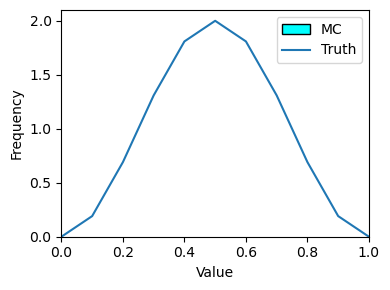

In [7]:

def pdf_sin2(x):
    return (2 * np.sin(np.pi*x)**2)

def sample_sin2_hitmiss(n):
    xAcc = []
    xRej = []
    nTry = 0
    # TODO: Implement this method.
    # It should take as input: n, the number of samples you want to
    # generate.
    # It should return all the accepted AND rejected MC samples as 
    # two lists or numpy arrays of numbers, as well as total number of tries.
    return nTry, xAcc, xRej

n, samples, rejected = sample_sin2_hitmiss(50_000)

fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(samples, bins=10, density=True, color='cyan', edgecolor='black', label='MC')

x = np.array([0.1 * i for i in range(0,11)])
ax.plot(x, pdf_sin2(x), label='Truth')
ax.set_xlabel("Value")
ax.set_ylabel("Frequency"); ax.set_xlim(0,1); ax.legend()
plt.tight_layout()

# TODO: Calculate the integral and the error on the integral as well as the efficiency
integral = 0
error = 0
efficiency = 0
print("Integral = ",integral,"+-",error)
print("Efficiency = ",efficiency)



## 4. Exercise — Hit‑miss with an **overestimate** $g(x)\ge f(x)$

Sample from:

$$
f(x) = 2\sin^2(\pi x), \quad x\in[0,1]
$$
once again. This time, use an overestimating function to **improve your efficiency**. Choose the overestimate to be the piecewise function $g(x)= 5x$ for $x < 0.5$ and $-5x+5$ for $x\geq0.5$. It is constructed such that $g(x)\ge f(x)$ on \([0,1]\).

**Tasks**
1. Check for yourself that $g(x) \geq f(x)$ on the interval.
2. Find the primitive for $g$ on the two intervals. Invert it. Use it to write up two equations for sampling from $g(x)$: one for $x < 0.5$ and one for $x \geq 0.5$.
3. Implement a function `sample_g(n)` which returns a list or array of numbers sampled from the piecewise function $g$, using inversion sampling. An easy way to do this, is as a two-step procedure:
   a. Choose whether to pick from one or the other interval by samling a random number and comparing to 0.5.
   b. Pick from the appropriate side, using the right expression.
4. Validate your `sample_g` function by comparing to the analytical expressions. Beware of normalization issues (Hint: divide the two piecewise functions with 1.25 each to normalize to unity).
5. Implement a function `sample_f(n)` which returns a list or array of numbers sampled from f, by:
   a. Selecting a $x_0$ from $g(x)$.
   b. Choose a $y = R * g(x_0)$
   c. Repeat until $y < f(x_0)$ is selected, then append to the list.
7. Compare efficiency (acceptance rates) vs the trivial envelope from previous exercise.


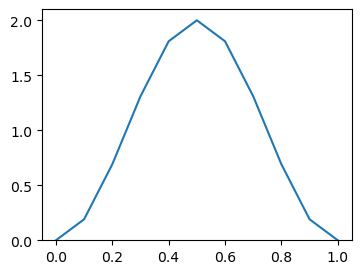

Efficiency =  100000.0


In [10]:

def g(x):
    if x < 0.5:
        return 5.*x
    else: 
        return (-5.*x +5)

def sample_g(n):
    ret = []
    # TODO: Implement this function
    return ret

def sample_f(n):
    ret = []
    nTry = 1
    # TODO: Implement this function
    return ret, (n/nTry)

fig, ax = plt.subplots(figsize=(4, 3))
samples, eff = sample_f(100000)
x = np.array([0.1 * i for i in range(0,11)])
ax.hist(samples, bins=10, density=True, color='cyan', edgecolor='black', label='MC')
ax.plot(x,pdf_sin2(x))

plt.show()

print("Efficiency = ",eff)



## 5. Exercise — Accept‑all with weights \(w = f/g\)

Instead of rejecting, **accept all proposals** generated from samling $g(x)$ and attach a weight $w(x)=f(x)/g(x)$.

**Tasks**
1. Sample $x$ from $g$ (same proposal as above), compute weights $w$ to reweight the proposal to $f$. Concretely, implement a new function `sample_f_weighted(n)` which outputs a list or array of values, and a list or array of weights, one for each value.
2. Build a **weighted histogram** and compare with the analytic $f(x)$.
3. Compute and report the **effective sample size**. Is reweighting working well here?
$$
\mu_{\mathrm{eff}} = \frac{1}{\sum_i \tilde{w}^2_i}\text{ with: } \tilde{w}_i = \frac{w_i}{\sum_j w_j}.
$$
4. Change proposal function to the simple overestimate from earlier. What happens to the effective sample size? Why?
5. Calculate $\mu_\mathrm{eff}/N$ where N is the actual number of samples generated.


Good mu =  inf  and  inf
Bad mu =  inf  and  inf


/var/folders/3p/st4pq4bs01107rspk9yxjdq40000gn/T/ipykernel_30700/8558742.py:6: RuntimeWarning: divide by zero encountered in scalar divide
  return 1./np.sum(wTilde**2)


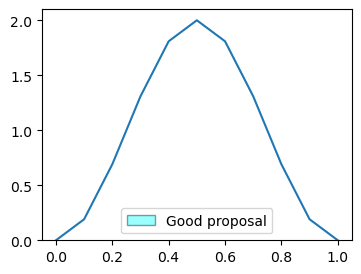

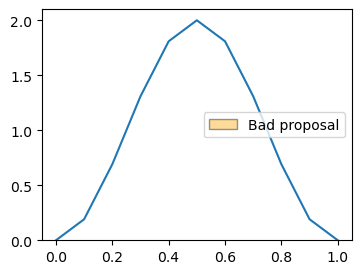

In [13]:
# You can use this implementation of mu_eff calculation
def muEff(weights):
    ws = np.array(weights)
    sumw = ws.sum()
    wTilde = ws / sumw
    return 1./np.sum(wTilde**2)
    
def sample_f_weighted(n):
    # TODO: Implement this function
    xg = []
    weights = []
    return xg, weights

def sample_f_weighted_box(n):
    # TODO: Implement this function
    xg = []
    weights = []
    return xg, weights

N = 100000
fig, ax = plt.subplots(figsize=(4, 3))
samples, weights = sample_f_weighted(N)
mu1 = muEff(weights)
x = np.array([0.1 * i for i in range(0,11)])
ax.hist(samples, bins=10, weights=weights,density=True, alpha=0.4, color='cyan', edgecolor='black', label='Good proposal')
ax.plot(x,pdf_sin2(x))

fig2, ax2 = plt.subplots(figsize=(4, 3))
samples, weights = sample_f_weighted_box(N)
mu2 = muEff(weights)
ax2.hist(samples, bins=10, weights=weights,density=True, alpha = 0.4, color='orange', edgecolor='black', label='Bad proposal')
ax2.plot(x,pdf_sin2(x))

print('Good mu = ',mu1, " and ",mu1/N)
print('Bad mu = ',mu2, " and ", mu2/N )

ax.legend()
ax2.legend()

plt.show()



## 6. Main task — Reweighting: simulate **fair** 10‑toss events with a **biased** coin

We define an **event** as $N=10$ independent coin tosses. The *target* is a fair coin with probability to get "heads" (labelled $+$) $p_+=p_{fair}=0.5$; 
we will **simulate with a biased coin** with some $p_+ = p_{biased} \neq 0.5$ and attach **event weights** to recover the fair distribution of the number of heads.

### Tasks
1. Fill in the missing `toss()` method in the `Coin` class. If you wish, you may also add proper guardrails for the class, such as ensuring that we always get an input $0 \leq p_+ \leq 1$ etc.
2. Fill in a `simulate` method in the `Event` class which will toss the coin $N$ times, as well as an `n_heads` method returning the number of heads tossed in that event.
3. Simulate a large number ($M=100,000$, reduce to $M=10,000$ if it is taking forever) of coin-toss "events" with $p_+=p_{fair} = 0.5$, and make a histogram of $P(\text{nHeads})$. Validate by controlling that the mean is at $5$ by visual inspection.
4. Simulate also a large number of coin-toss "events" with $p_+=p_{biased}=0.8$, and make a histogram of $P(\text{nHeads})$. Validate by controlling that the mean is at $8$ by visual inspection.

The probability for getting $n$ heads out of $N$ coin tosses with a coin having some $p_+$ is:

$$
   P_n(p_+) = {N \choose n}p_+^n  (1-p_+)^{N-n}
$$
We can calculate this probability with 1) the "fair coin" parameter $p_+ = p_{fair}$ and with 2) the "biased coin" parameter $p_+ = p_{biased}$. The equality also works the other way around. An event with exactly $n=n_0$ heads, will have the probability given by the equation. Thus, we can simulate events with one value of the parameter $p_+$, and calculate what probability this event would have if the parameters were different. 
The *event weight* to reweight between $p_+ = p$ and $p_+ = p'$ for a given event is then:
$$
    w = \frac{P_n(p')}{P_n(p)}.
$$
In both numerator and denominator, we have to use the *generated value* of $n$ to calculate the weight. This means that the binomial coefficients drop out, and we are left with the expression:
$$
    w = \left(\frac{p'}{p}\right)^n \left(\frac{1 - p'}{1 - p}\right)^{N-n}.
$$
A weight larger than one means this outcome was underrepresented in the biased simulation; a small weight means it was overrepresented.
5. Add a new method `weight(p_prime)` to the `Event` class, which will calculate the event weight according to the above equation. When simulating the $p=0.8$ events, also gather event weights. Make a histogram of the $p=0.8$ events *reweighted to* $p'=0.5$. Use the given method to calculate $\mu_{eff}$ and report $\mu_{eff}/M$ (where $M$ is the number of samples generated).
6. For $p=\{0.1,0.2,...,0.9\}$ and $p'=0.5$, plot $\mu_{eff}/M$ as function of $p$.

99999.99999999994


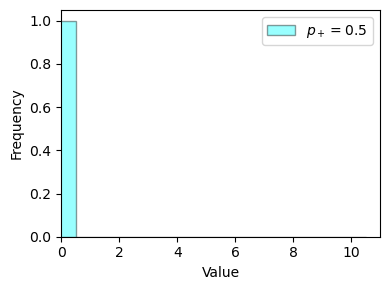

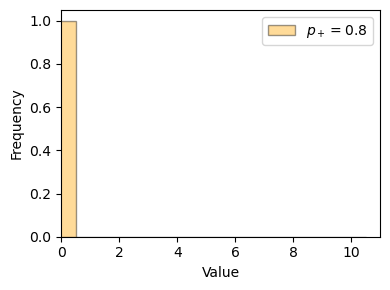

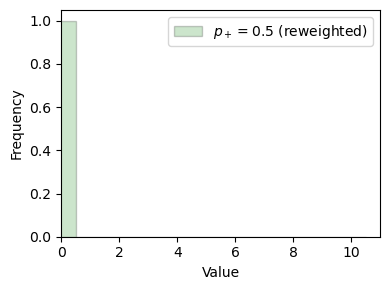

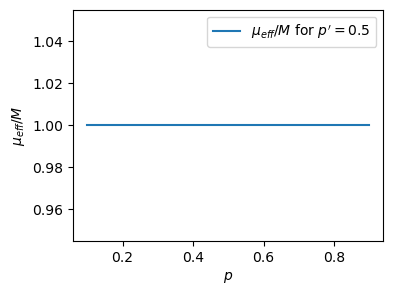

In [15]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(12345)

class Coin:
    def __init__(self, p_plus=0.5):
        self.p_plus = p_plus
        
    def toss(self):
        # TODO: implement: return 1 with probability p_plus, else 0
        return 0

class Event:
    def __init__(self, coin: Coin, N = 10):
        self.coin = coin
        self.N = N
        self.outcomes = None  # list of n ints
        
    def simulate(self): 
        # TODO: simulate N tosses and store in self.outcomes
        self.outcomes = []
        return self.outcomes

        
    def n_heads(self):   
        # TODO: return number of heads in self.outcomes
        return 0

    def weight(self, p_prime):   
        # TODO: compute event weight: (p_prime/p)**n * ((1-p_prime)/(1-p))**(N-n)
        return 1.0

# You can use this implementation of mu_eff calculation
def muEff(weights):
    ws = np.array(weights)
    sumw = ws.sum()
    wTilde = ws / sumw
    return 1./np.sum(wTilde**2)

M = 100000
N = 10
c5 = Coin()
e5 = Event(c5, N)
c8 = Coin(0.8)
e8 = Event(c8, N)
samples5 = []
samples8 = []
weights = []

for _ in range(M):
    e5.simulate()
    samples5.append(e5.n_heads())
    e8.simulate()
    samples8.append(e8.n_heads())
    weights.append(e8.weight(0.5))

bins = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5]
fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(samples5, bins=bins,density=True, alpha=0.4, color='cyan', edgecolor='black', label=r'$p_+ = 0.5$')
ax.set_xlabel("Value")
ax.set_ylabel("Frequency"); ax.set_xlim(0,11); ax.legend()
plt.tight_layout()

fig2, ax2 = plt.subplots(figsize=(4, 3))
ax2.hist(samples8, bins=bins,density=True, alpha=0.4, color='orange', edgecolor='black', label=r'$p_+ = 0.8$')
ax2.set_xlabel("Value")
ax2.set_ylabel("Frequency"); ax2.set_xlim(0,11); ax2.legend()
plt.tight_layout()

fig3, ax3 = plt.subplots(figsize=(4, 3))
ax3.hist(samples8, bins=bins, weights=weights, density=True, alpha=0.2, color='green', edgecolor='black', label=r'$p_+ = 0.5$ (reweighted)')

ax3.set_xlabel("Value")
ax3.set_ylabel("Frequency"); ax3.set_xlim(0,11); ax3.legend()
plt.tight_layout()

print(muEff(weights))

ps = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
allMuEff = []
for pp in ps:
    c = Coin(pp)
    e = Event(c, N)
    w = []
    for _ in range(M):
        e.simulate()
        w.append(e.weight(0.5))
    allMuEff.append(muEff(w))

fig4, ax4 = plt.subplots(figsize=(4, 3))
ax4.plot(ps, np.array(allMuEff)/M, label=r"$\mu_{eff}/M$ for $p'=0.5$")
ax4.set_xlabel(r'$p$')
ax4.set_ylabel(r'$\mu_{eff}/M$')
ax4.legend()
plt.show()